In [67]:
pip install niftystocks

In [68]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from niftystocks import ns
import matplotlib.dates as mdates
import scipy.stats as stats
from scipy.stats import chi2

First we backtest a simple momentum trading strategy. Following are the rules.
- Initial capital = 500,000 ₹
- Maximum positions = 20
- Stocks to be traded: NSE 100 (top 100 stocks by market cap listed in NSE)
- Entry: On every Monday, check if the stock broke 52-week high last Friday, and 20 day average turnover (closing price $\times$ volume) is above 100,000,000 ₹
- (Trailing) Stoploss: $\max(0.7\times \text{entry price}, \text{previous 10 weeks low})$ (updated every Monday).
- Target: $1.6 \times \text{entry price}$

/tmp/ipykernel_2576/1540458696.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date, interval='1d')
[*********************100%***********************]  100 of 100 completed
ERROR:yfinance:
8 Failed downloads:
ERROR:yfinance:['PEL.NS', 'HDFC.NS', 'MCDOWELL-N.NS', 'CADILAHC.NS', 'TATAMOTORS.NS', 'ADANITRANS.NS', 'LTI.NS', 'MOTHERSUMI.NS']: YFTzMissingError('possibly delisted; no timezone found')
/tmp/ipykernel_2576/1540458696.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close_prices = raw_data['Close'].fillna(method='ffill')
/tmp/ipykernel_2576/1540458696.py:106: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_data = yf.download(nifty_ticker, start=start_date, end=end_date, interval='1d')
[*********************100%***********************]  1 of 1 completed


--- Backtest Results ---
Total Trades: 152
Max Drawdown: 12.36%
Final Value: ₹683,863.00


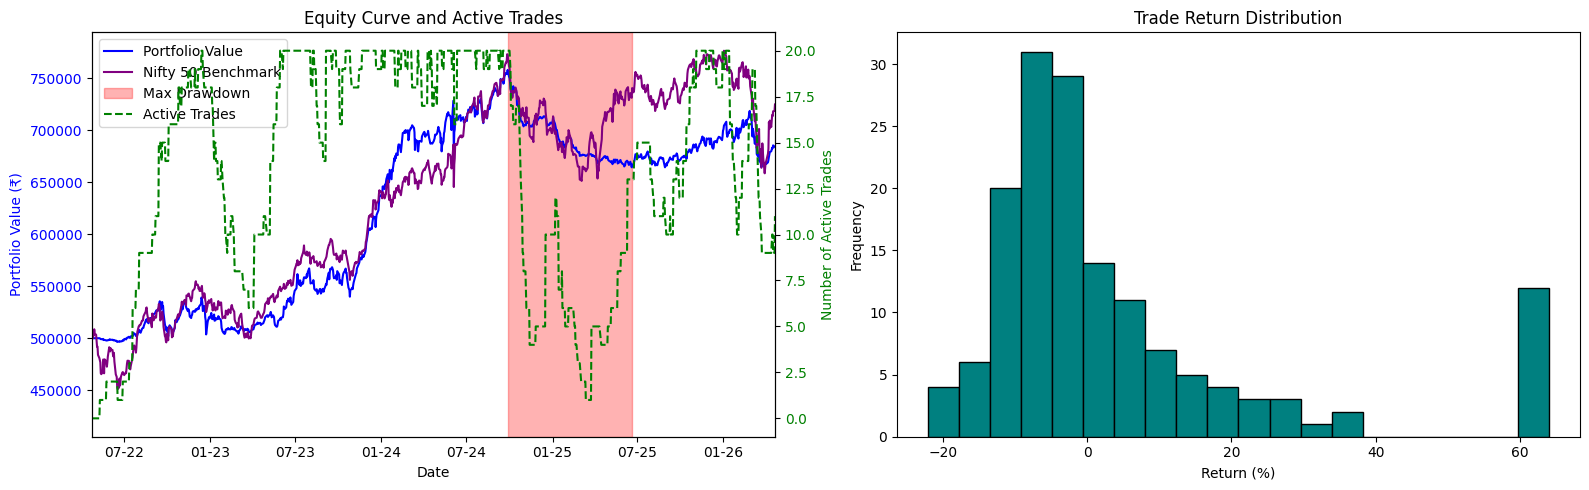

In [69]:
initial_capital = 500_000
max_positions = 20
turnover_threshold = 100_000_000
Years = 5 # For backtesting
start_date = (datetime.now() - timedelta(days=Years*365)).strftime('%Y-%m-%d')
end_date = datetime.now().strftime('%Y-%m-%d')

def run_backtest():
    nifty_tickers_raw = ns.get_nifty100()
    tickers = [t + '.NS' for t in nifty_tickers_raw] # Append '.NS' for yfinance compatibility
    raw_data = yf.download(tickers, start=start_date, end=end_date, interval='1d')

    # Use 'Close' for prices and 'Volume' for liquidity
    close_prices = raw_data['Close'].fillna(method='ffill')
    volumes = raw_data['Volume'].fillna(0)

    # Pre-calculate Indicators
    high_52 = close_prices.rolling(window=252).max()
    low_10 = close_prices.rolling(window=50).min()

    # Calculate Daily Turnover (Price * Volume) and smooth it with a 20-day MA
    daily_turnover = close_prices * volumes
    avg_turnover = daily_turnover.rolling(window=20).mean()

    cash = initial_capital
    portfolio_history = []
    active_trades = []
    completed_trades = []

    for date, row in close_prices.iterrows():
        # Update Portfolio Value
        current_val = cash
        for trade in active_trades:
            current_val += row[trade['symbol']] * trade['qty']
        portfolio_history.append({'Date': date, 'Value': current_val, 'Num_Trades': len(active_trades)})

        # Manage Exits
        for trade in active_trades[:]:
            curr_price = row[trade['symbol']]

            # Trailing SL update every Monday
            if date.weekday() == 0:
                trade['stop_loss'] = max(trade['stop_loss'], low_10.loc[date, trade['symbol']])

            # Exit Conditions
            if curr_price >= trade['target'] or curr_price <= trade['stop_loss']:
                cash += curr_price * trade['qty']
                ret = (curr_price - trade['entry_price']) / trade['entry_price']
                completed_trades.append(ret * 100)
                active_trades.remove(trade)

        # Check Entries (Monday Mornings)
        if date.weekday() == 0 and len(active_trades) < max_positions:
            prev_friday = date - timedelta(days=3)

            if prev_friday in high_52.index:
                # Rank candidates by how far they are above 52W high (Momentum strength)
                potential_picks = []
                for symbol in tickers:
                    if symbol not in row or np.isnan(row[symbol]): continue

                    # Filter 1: 52-Week high breakout
                    # Filter 2: 20-day average turnover > 10 Crores
                    if (close_prices.loc[prev_friday, symbol] >= high_52.loc[prev_friday, symbol] and
                        avg_turnover.loc[prev_friday, symbol] >= turnover_threshold):

                        if not any(t['symbol'] == symbol for t in active_trades):
                            potential_picks.append(symbol)

                for symbol in potential_picks:
                    if len(active_trades) >= max_positions: break

                    entry_price = row[symbol]
                    allocation = initial_capital / max_positions
                    if cash >= allocation:
                        qty = allocation // entry_price
                        if qty > 0:
                            cash -= qty * entry_price
                            active_trades.append({
                                'symbol': symbol, 'entry_price': entry_price, 'qty': qty,
                                'target': entry_price * 1.6,
                                'stop_loss': max(entry_price * 0.7, low_10.loc[date, symbol])
                            })

    return pd.DataFrame(portfolio_history), completed_trades, active_trades

# Run and Analyze
port_df, trade_rets, final_active_trades = run_backtest()
port_df['Drawdown'] = (port_df['Value'].cummax() - port_df['Value']) / port_df['Value'].cummax()

print(f"\n--- Backtest Results ---")
print(f"Total Trades: {len(trade_rets)}")
print(f"Max Drawdown: {port_df['Drawdown'].max()*100:.2f}%")
print(f"Final Value: ₹{port_df['Value'].iloc[-1]:,.2f}")

# Find the maximum drawdown period
max_drawdown_index = port_df['Drawdown'].idxmax()
max_drawdown_end_date = port_df.loc[max_drawdown_index, 'Date']

peak_value_before_max_drawdown = port_df.loc[:max_drawdown_index, 'Value'].cummax().iloc[-1]
peak_index = port_df.loc[:max_drawdown_index][port_df.loc[:max_drawdown_index, 'Value'] == peak_value_before_max_drawdown].index[0]
max_drawdown_start_date = port_df.loc[peak_index, 'Date']

# --- Nifty 50 Benchmark ---
nifty_ticker = '^NSEI'
nifty_data = yf.download(nifty_ticker, start=start_date, end=end_date, interval='1d')
nifty_close_prices = nifty_data['Close'].dropna()

# Align Nifty 50 data with portfolio data dates
port_df['Date'] = pd.to_datetime(port_df['Date'])
nifty_close_prices.index = pd.to_datetime(nifty_close_prices.index)

# Resample Nifty data to match the trading days in port_df
nifty_aligned_prices = nifty_close_prices.reindex(port_df['Date']).ffill().bfill()

# Calculate Nifty 50 value if initial_capital was invested
if not nifty_aligned_prices.empty:
    # Determine the date for the start of the plot's x-axis
    start_date_dt = datetime.strptime(start_date, '%Y-%m-%d')
    one_year_later = start_date_dt + timedelta(days=365)

    # Find the first date in port_df that is >= one_year_later
    idx_plot_start = (port_df['Date'] >= one_year_later).idxmax()
    actual_plot_start_date = port_df.loc[idx_plot_start, 'Date']

    # Get the Nifty 50 price at this actual_plot_start_date
    nifty_price_at_plot_start = nifty_aligned_prices.loc[actual_plot_start_date, '^NSEI']

    # Scale the Nifty_Value column so that at 'one_year_later' it equals initial_capital
    port_df['Nifty_Value'] = (nifty_aligned_prices['^NSEI'].values / nifty_price_at_plot_start) * initial_capital

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Equity Curve
ax1.plot(port_df['Date'], port_df['Value'], label='Portfolio Value', color='blue')

# Plot Nifty 50 Value if available
if 'Nifty_Value' in port_df.columns and not port_df['Nifty_Value'].isnull().all():
    ax1.plot(port_df['Date'], port_df['Nifty_Value'], label='Nifty 50 Benchmark', color='purple')

ax1.set_title("Equity Curve and Active Trades")
ax1.set_xlabel("Date")
ax1.set_ylabel("Portfolio Value (₹)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%y'))

# Set x-axis limits to start 1 year after the original start_date
start_date_dt = datetime.strptime(start_date, '%Y-%m-%d')
one_year_later = start_date_dt + timedelta(days=365)
ax1.set_xlim(one_year_later, port_df['Date'].max())

# Highlight max drawdown phase
ax1.axvspan(max_drawdown_start_date, max_drawdown_end_date, color='red', alpha=0.3, label='Max Drawdown')

# Create a second y-axis for the number of active trades
ax1_2 = ax1.twinx()
ax1_2.plot(port_df['Date'], port_df['Num_Trades'], label='Active Trades', color='green', linestyle='--')
ax1_2.set_ylabel("Number of Active Trades", color='green')
ax1_2.tick_params(axis='y', labelcolor='green')

# Add legends for both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1_2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left')

# Trade Return Distribution
ax2.hist(trade_rets, bins=20, edgecolor='black', color='teal')
ax2.set_title("Trade Return Distribution")
ax2.set_xlabel("Return (%)")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Now we check the competence of the strategy by calculating alpha, beta, and sharpe ratio.

We calculate alpha and beta using a couple of methods.
1. Using linear regression

- $Y = \beta X + \alpha$,

where $Y$ represents the (risk free adjusted) portfolio return, and $X$ represents the (risk free adjusted) market return (Nifty 50 in this case), $\alpha$ is the daily alpha.   

2. Using formulas

- $\beta = \frac{\text{Cov}(R_p, R_m)}{\text{Var}(R_m)}$

- $\alpha = \text{Avg}(R_p) - \left[R_f + \beta \times (\text{Avg}(R_m) - R_f)\right]$

Sharpe ratio is calculated using the following formula.

- $\text{Sharpe Ratio} = \frac{\text{Avg}(R_p) - R_f}{\sigma_p}$

- $\text{Sharpe Ratio}_{\text{Annual}} = \text{Sharpe Ratio}_{\text{Daily}} \times \sqrt{252}$

In [70]:
nifty_ticker = '^NSEI'

# Calculate the date 1 year after the start_date
start_date_dt = datetime.strptime(start_date, '%Y-%m-%d')
one_year_later = start_date_dt + timedelta(days=365)

# Fetch Nifty 50 data
nifty_data = yf.download(nifty_ticker, start=str(one_year_later.date()), end=end_date, interval='1d')
nifty_returns = nifty_data['Close'].pct_change().dropna()

portfolio_returns_df = port_df.set_index('Date') # Ensure portfolio_daily_returns has a DatetimeIndex for proper alignment

# Filter portfolio_returns_df to start 1 year after the start_date
filtered_portfolio_returns_df = portfolio_returns_df[portfolio_returns_df.index >= one_year_later]
portfolio_daily_returns = filtered_portfolio_returns_df['Value'].pct_change().dropna()

common_dates = portfolio_daily_returns.index.intersection(nifty_returns.index) # Ensure both series have the same dates
aligned_portfolio_returns = portfolio_daily_returns.loc[common_dates]
aligned_nifty_returns = nifty_returns.loc[common_dates]
risk_free_rate_daily = 0.07 / 252 # This rate is for ₹

# Subtract risk-free rate to get excess returns
excess_portfolio_returns = aligned_portfolio_returns - risk_free_rate_daily
excess_nifty_returns = aligned_nifty_returns.squeeze() - risk_free_rate_daily
beta, alpha_raw, r_value, p_value, std_err = stats.linregress(excess_nifty_returns, excess_portfolio_returns)
annualized_alpha = alpha_raw * 252 * 100 # In percentage

print(f"\n--- Alpha and Beta Calculation (vs Nifty 50) ---")
print(f"Beta: {beta:.2f}")
print(f"Annualized Alpha: {annualized_alpha:.2f}%")

# Calculate Beta using the Covariance/Variance formula
beta_cov_var = aligned_portfolio_returns.cov(excess_nifty_returns) / aligned_nifty_returns.squeeze().var()

# Calculate Alpha using the formula
mean_excess_portfolio_returns = excess_portfolio_returns.mean()
mean_excess_nifty_returns = excess_nifty_returns.mean()

alpha_formula_daily = mean_excess_portfolio_returns - (beta_cov_var * mean_excess_nifty_returns)
annualized_alpha_formula = alpha_formula_daily * 252 * 100

print(f"\n--- Alpha and Beta Calculation (using formulas) ---")
print(f"Beta (Covariance/Variance Formula): {beta_cov_var:.2f}")
print(f"Annualized Alpha (Formula-based): {annualized_alpha_formula:.2f}%")

portfolio_mean_daily_return = portfolio_daily_returns.mean()
portfolio_std_daily_return = portfolio_daily_returns.std()

# Calculate daily Sharpe Ratio
sharpe_ratio_daily = (portfolio_mean_daily_return - risk_free_rate_daily) / portfolio_std_daily_return

# Annualize the Sharpe Ratio (assuming 252 trading days in a year)
sharpe_ratio_annualized = sharpe_ratio_daily * np.sqrt(252)

print(f"\n--- Portfolio Sharpe Ratio ---")
print(f"Daily Sharpe Ratio: {sharpe_ratio_daily:.4f}")
print(f"Annualized Sharpe Ratio: {sharpe_ratio_annualized:.4f}")

/tmp/ipykernel_2576/2917736187.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_data = yf.download(nifty_ticker, start=str(one_year_later.date()), end=end_date, interval='1d')
[*********************100%***********************]  1 of 1 completed


--- Alpha and Beta Calculation (vs Nifty 50) ---
Beta: 0.49
Annualized Alpha: -0.20%

--- Alpha and Beta Calculation (using formulas) ---
Beta (Covariance/Variance Formula): 0.49
Annualized Alpha (Formula-based): -0.20%

--- Portfolio Sharpe Ratio ---
Daily Sharpe Ratio: 0.0097
Annualized Sharpe Ratio: 0.1547


- $\beta$ is pretty good since it is significantly smaller than 1. This value suggests that this strategy is less volatile and less sensitive to market fluctuations.
- $\alpha$ is the percentage by which the strategy beats the market. In this case, the percentage is positive, but not great.
- Bigger the sharpe ratio the better. A sharpe ratio is considered good if it is greater than 1, so the current value for the strategy is suboptimal.

Following is the list of stocks in the portfolio with their LTPs and the total poertfolio value. We use these to perform Value at Risk (VaR) analysis on the current portfolio.

In [71]:
# Convert the list of dictionaries to a DataFrame
active_trades_df = pd.DataFrame(final_active_trades)

# Select and rename columns for display
active_trades_display = active_trades_df[['symbol', 'qty']].rename(columns={'symbol': 'Symbol', 'qty': 'Quantity'})
portfolio_holdings = active_trades_display.copy()

# Fetch current prices
current_prices = {}
for symbol in portfolio_holdings['Symbol']:
  ticker_data = yf.download(symbol, period='1d', interval='1m', progress=False)
  if not ticker_data.empty:
      # Use the last available closing price for the current day and convert to scalar
      current_prices[symbol] = ticker_data['Close'].iloc[-1].item()
  else:
      # Fallback for when '1m' interval might not return data for the current day
      # or if the market is closed and last day's close is needed.
      ticker_data = yf.download(symbol, period='2d', interval='1d', progress=False)
      current_prices[symbol] = ticker_data['Close'].iloc[-1].item()

portfolio_holdings['Current_Price'] = portfolio_holdings['Symbol'].map(current_prices)

# Calculate Current_Value
portfolio_holdings['Current_Value'] = portfolio_holdings['Quantity'] * portfolio_holdings['Current_Price']
current_portfolio_value = portfolio_holdings['Current_Value'].sum()
portfolio_holdings['Weight'] = portfolio_holdings['Current_Value'] / current_portfolio_value

print(f"\n--- Portfolio Holdings Analysis ---")
print(f"Current holdings value: ₹{current_portfolio_value:,.2f}")
display(portfolio_holdings)

/tmp/ipykernel_2576/1027000371.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(symbol, period='1d', interval='1m', progress=False)
/tmp/ipykernel_2576/1027000371.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(symbol, period='1d', interval='1m', progress=False)
/tmp/ipykernel_2576/1027000371.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(symbol, period='1d', interval='1m', progress=False)
/tmp/ipykernel_2576/1027000371.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(symbol, period='1d', interval='1m', progress=False)
/tmp/ipykernel_2576/1027000371.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(symbol, period='1d', interval='1m', progress=False)
/tmp/ipykernel_2576/


--- Portfolio Holdings Analysis ---
Current holdings value: ₹291,980.35


/tmp/ipykernel_2576/1027000371.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(symbol, period='1d', interval='1m', progress=False)


,Symbol,Quantity,Current_Price,Current_Value,Weight
0,TORNTPHARM.NS,6.0,4075.699951,24454.199707,0.083753
1,VEDL.NS,50.0,758.200012,37910.000610,0.129838
2,NMDC.NS,318.0,88.650002,28190.700485,0.096550
3,NTPC.NS,69.0,405.250000,27962.250000,0.095768
4,ONGC.NS,90.0,283.250000,25492.500000,0.087309
5,SIEMENS.NS,7.0,3840.000000,26880.000000,0.092061
6,LUPIN.NS,10.0,2311.000000,23110.000000,0.079149
7,AUROPHARMA.NS,19.0,1420.000000,26980.000000,0.092403
8,TITAN.NS,5.0,4455.000000,22275.000000,0.076289
9,ADANIPORTS.NS,15.0,1587.500000,23812.500000,0.081555


Now we find Value at Risk (VaR) values using the following three methods.
1. Historical method
  - On the momentum strategy
  - On the current holdings
2. Variance Covariance Method
3. Monte Carlo Simulation Method

The following shows VaR analysis on the momntum strategy using the historical method.

This is the simplest method to execute. We gather all the daily returns, sort them in an ascending order, and pick return at the appropriate rank as per the confidence interval. Finally, we multiply the returns by the portfolio value to get (1-day) VaR number.

In [72]:
confidence_interval = 0.99
alpha = 1 - confidence_interval # This is the level of significane. This alpha is different from the alpha we calculated earlier

sorted_returns = portfolio_daily_returns.sort_values()
n = len(sorted_returns)
VaR_position = int(np.ceil(n * alpha))
VaR_return = sorted_returns.iloc[VaR_position - 1] # -1 because counting starts from 0
VaR_amount = VaR_return * current_portfolio_value
print(f"We can be {confidence_interval*100}% sure that the daily loss won't exceed ₹{-VaR_amount:.0f}.")

We can be 99.0% sure that the daily loss won't exceed ₹5118.


The following shows VaR analysis on the current holdings using the historical method.

In [73]:
def calculate_hist_var_with_actual_weights(holdings, capital, ci, YEARS = 5):
    if not holdings:
        print("No active positions to analyze.")
        return

    # Fetch Current Prices and Tickers
    tickers = [h['symbol'] for h in holdings]
    start_date = (datetime.now() - timedelta(days=YEARS*365)).strftime('%Y-%m-%d')

    data = yf.download(tickers, start=start_date, interval='1d', progress=False)['Close']
    data = data.ffill()

    # Calculate Current Market Weights
    # Weight = (Qty * Latest Close Price) / Total Capital (x)
    latest_prices = data.iloc[-1]
    weights_dict = {}

    for h in holdings:
        symbol = h['symbol']
        current_val = h['qty'] * latest_prices[symbol]
        weights_dict[symbol] = current_val / capital

    weights_series = pd.Series(weights_dict)

    # Calculate Daily Returns
    if len(tickers) == 1:
        daily_returns = data.pct_change().dropna().to_frame()
    else:
        daily_returns = data.pct_change().dropna()

    # Portfolio Returns (Weighted)
    portfolio_returns = daily_returns.dot(weights_series)

    # Historical VaR Calculation
    sorted_returns = portfolio_returns.sort_values(ascending=True)
    n = len(sorted_returns)
    alpha = 1 - ci
    var_index = int(np.ceil(n * alpha))
    var_return_val = sorted_returns.iloc[var_index - 1]
    VaR_amount_1b = var_return_val * capital

    return -VaR_amount_1b

# Execution

trial_portfolio = {
    "RELIANCE.NS": 0.2,
    "TCS.NS": 0.3,
    "HDFCBANK.NS": 0.1,
    "ICICIBANK.NS": 0.15,
    "INFY.NS": 0.25,
}
# holdings = [{"symbol": symbol, "qty": qty} for symbol, qty in trial_portfolio.items()] # Update current_portfolio_value
holdings = final_active_trades
print(f"We can be {confidence_interval*100}% sure that the daily loss won't exceed ₹{calculate_hist_var_with_actual_weights(holdings, current_portfolio_value, confidence_interval):.0f} with the current stock holdings.")


/tmp/ipykernel_2576/4258120997.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, interval='1d', progress=False)['Close']


We can be 99.0% sure that the daily loss won't exceed ₹8398 with the current stock holdings.


The following shows VaR analysis on current holdings using Variance Covariance method.

Assumptions:
1. Returns follow normal distribution
2. Standard deviation and correlation is time-independent

In this method, we consider the covariance matrix of the stocks, say $C$, and let $W$ be the row matrix of the weights. Then we get the variance of the portfolio by

$\text{Var}_p = W \times C \times W^T$

Finally, we get VaR using the following formula:

$\text{VaR} = \left[\text{Avg}(R_p) + (\sigma_p \times \text{Z-value}(\text{alpha})) \right] \times \text{portfolio value}$


In [74]:
def portfolio_returns(holdings, capital, YEARS = 5):
    if not holdings:
        print("No active positions to analyze.")
        return

    # Fetch Current Prices and Tickers
    tickers = [h['symbol'] for h in holdings]
    start_date = (datetime.now() - timedelta(days=YEARS*365)).strftime('%Y-%m-%d')

    print(f"Fetching {YEARS}y data for {len(tickers)} assets...")
    data = yf.download(tickers, start=start_date, interval='1d', progress=False)['Close']
    data = data.ffill()

    # Calculate Current Market Weights
    latest_prices = data.iloc[-1]
    weights_dict = {}

    for h in holdings:
        symbol = h['symbol']
        current_val = h['qty'] * latest_prices[symbol]
        weights_dict[symbol] = current_val / capital

    weights_series = pd.Series(weights_dict)

    # Calculate Daily Returns
    if len(tickers) == 1:
        daily_returns = data.pct_change().dropna().to_frame()
    else:
        daily_returns = data.pct_change().dropna()

    # Portfolio Returns (Weighted)
    portfolio_returns = daily_returns.dot(weights_series)

    return portfolio_returns

def calculate_vcv_var(holdings, capital, ci, YEARS = 5):
    symbols = portfolio_holdings['Symbol'].tolist()

    # Define the period for historical data (5 years)
    historical_end_date = datetime.now()
    historical_start_date = historical_end_date - timedelta(days=5*365)

    # Fetch historical daily prices
    historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']

    # Calculate VaR step-by-step
    daily_log_returns = (np.log(historical_data / historical_data.shift(1))).dropna() # Here we use a slightly different formula for the returns.
    cov_matrix = daily_log_returns.cov()
    Variance_Portfolio = np.matmul(np.matmul(np.array(portfolio_holdings['Weight']), np.array(cov_matrix)), np.array(portfolio_holdings['Weight']).T)
    alpha = 1 - ci
    VaR_Cov = (portfolio_returns(holdings, current_portfolio_value, confidence_interval).mean() + np.sqrt(Variance_Portfolio) * stats.norm.ppf(alpha)) * current_portfolio_value

    return -VaR_Cov

print(f"We can be {confidence_interval*100}% sure that the daily loss won't exceed ₹{calculate_vcv_var(holdings, current_portfolio_value, confidence_interval):.0f} with the current stock holdings.")


/tmp/ipykernel_2576/196122140.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']
[*********************100%***********************]  11 of 11 completed
/tmp/ipykernel_2576/196122140.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, interval='1d', progress=False)['Close']


Fetching 0.99y data for 11 assets...
We can be 99.0% sure that the daily loss won't exceed ₹7454 with the current stock holdings.


The following shows VaR analysis on current holdings using Monte Carlo Simulation method.

Assumptions:
1. Stock prices follow Geometric Brownian Motion (GBM).
2. We assume the randomness factor ($dW_t)$ follows normal distribution. One can choose a different, fatter tail distribution too.

We get the correlation matrix of the current stock returns in the holding. Then we get its Cholesky decomposition and multiply it with an (uncorrelated) random normal matrix to get a correlated random normal matrix. Then we get individual stock prices arising from the solution of GBM assumption of stock prices.

The stochastic differential equation of Geometric Brownian Motion (GBM) is as follows:

$\frac{dS}{dt} = \mu S dt + \sigma S dW_t$

and the solution is as follows:

$S_t = S_0\cdot e^{\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t}$

 Then we get the portfolio return by taking the weighted average of stock returns. We then apply the historical method procedure to get the VaR number.  

In [75]:
# Simulating stock prices
def GBM_Solution(S0, mu, sigma, t, omega):
  return S0 * np.exp((mu - 0.5 * sigma**2)*t + sigma*omega)

def calculate_MC_var(holdings, capital, ci, YEARS = 5, num_simulations = 10000):
    symbols = portfolio_holdings['Symbol'].tolist()
    current_prices_array = np.array(list(current_prices.values()))

    # Define the period for historical data (5 years)
    historical_end_date = datetime.now()
    historical_start_date = historical_end_date - timedelta(days=5*365)

    # Fetch historical daily prices
    historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']

    # Calculate VaR step-by-step
    daily_log_returns = (np.log(historical_data / historical_data.shift(1))).dropna() # Here we use a slightly different formula for the returns
    cov_matrix = daily_log_returns.cov()
    Corr_matrix = daily_log_returns.corr()
    Cholesky_decomp = np.linalg.cholesky(Corr_matrix)
    rng = np.random.default_rng()
    Uncorr_random_matrix = rng.standard_normal(size=(num_simulations, len(symbols)))
    Corr_random_matrix = (np.matmul(Cholesky_decomp, Uncorr_random_matrix.T)).T
    Cov_matrix = np.array(cov_matrix)

    # Now we directly calculate the stock returns by considering the one-step solution to the GBM
    simulated_stock_returns  = daily_log_returns.mean().values + daily_log_returns.std().values * Corr_random_matrix
    simulated_portfolio_returns = np.sum(simulated_stock_returns * np.array(portfolio_holdings['Weight']), axis=1)
    sorted_simulated_returns = np.sort(simulated_portfolio_returns)
    alpha = 1 - ci
    VaR_position = int(np.ceil(num_simulations * alpha))
    VaR_return_MC = sorted_simulated_returns[VaR_position - 1]
    VaR_amount_MC = VaR_return_MC * current_portfolio_value

    return -VaR_amount_MC

print(f"We can be {confidence_interval*100}% sure that the daily loss won't exceed ₹{calculate_MC_var(holdings, current_portfolio_value, confidence_interval):.0f}.")


/tmp/ipykernel_2576/2728276362.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']
[*********************100%***********************]  11 of 11 completed

We can be 99.0% sure that the daily loss won't exceed ₹7533.


Now we compare all three methods at once, with various confidence levels.

In [76]:
confidence_levels = [0.99, 0.95, 0.90]
var_results = {}

# --- Populate results dictionary ---
for ci in confidence_levels:
    ci_label = f'{ci*100:.0f}%'
    confidence_interval = ci
    # Historical VaR (Current Holdings)
    var_results.setdefault('Historical (Holdings)', {})[ci_label] = \
        round(calculate_hist_var_with_actual_weights(holdings, current_portfolio_value, confidence_interval), 0)

    # Variance-Covariance VaR
    var_results.setdefault('Variance-Covariance', {})[ci_label] = \
        round(calculate_vcv_var(holdings, current_portfolio_value, confidence_interval), 0)

    # Monte Carlo Simulation VaR
    var_results.setdefault('Monte Carlo Simulation', {})[ci_label] = \
        round(calculate_MC_var(holdings, current_portfolio_value, confidence_interval), 0)

# Create DataFrame from results
var_table_df = pd.DataFrame(var_results).T
var_table_df.index.name = 'VaR Method'

# Display the table
print("--- VaR Results Summary (Absolute Loss in ₹) ---")
display(var_table_df)

/tmp/ipykernel_2576/4258120997.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, interval='1d', progress=False)['Close']
/tmp/ipykernel_2576/196122140.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']
[*********************100%***********************]  11 of 11 completed
/tmp/ipykernel_2576/196122140.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, interval='1d', progress=False)['Close']


Fetching 0.99y data for 11 assets...


/tmp/ipykernel_2576/2728276362.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']
[*********************100%***********************]  11 of 11 completed
/tmp/ipykernel_2576/4258120997.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, interval='1d', progress=False)['Close']
/tmp/ipykernel_2576/196122140.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']
[*********************100%***********************]  11 of 11 completed
/tmp/ipykernel_2576/196122140.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, interval='1d', progres

Fetching 0.95y data for 11 assets...


/tmp/ipykernel_2576/2728276362.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']
[*********************100%***********************]  11 of 11 completed
/tmp/ipykernel_2576/4258120997.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, interval='1d', progress=False)['Close']
/tmp/ipykernel_2576/196122140.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']
[*********************100%***********************]  11 of 11 completed
/tmp/ipykernel_2576/196122140.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, interval='1d', progres

Fetching 0.9y data for 11 assets...


/tmp/ipykernel_2576/2728276362.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data = yf.download(symbols, start=historical_start_date, end=historical_end_date, interval='1d')['Close']
[*********************100%***********************]  11 of 11 completed


--- VaR Results Summary (Absolute Loss in ₹) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),8398.0,5561.0,3650.0
Variance-Covariance,7454.0,5171.0,3952.0
Monte Carlo Simulation,7533.0,5150.0,4030.0


We get similar, yet pretty different VaR numbers from different methods. As one might expect, the VaR numbers are smaller for smaller confidence levels.

Now we test the strategy by using the VaR numbers with the help of the following two methods:
1. Traffic light approach
2. Kupiec test

Let us first look at trafic light approach. The upshot here is: count the number of beaches (instances when daily loss was more than the 99% CI VaR number) during the last 252 trading days. If the number is betwen 0-4, it is rated 'Green', if it is between '5-9' is it rated 'Yellow', otherwise, it is rated 'Red'. Hence the name traffic light.

In [77]:
num_trading_days = 252 # number of trading days for breach analysis

# --- Fetch historical data for current holdings ---
symbols = portfolio_holdings['Symbol'].tolist()
historical_end_date_breach = datetime.now()
historical_start_date_breach = historical_end_date_breach - timedelta(days=Years*365)
historical_data_for_holdings = yf.download(symbols, start=historical_start_date_breach, end=historical_end_date_breach, interval='1d')['Close']
historical_data_for_holdings = historical_data_for_holdings.ffill()

# Need to calculate portfolio daily returns for the last 252 days based on current holdings' historical data
data_for_breach_check_full = historical_data_for_holdings.copy()
latest_prices_for_weights = data_for_breach_check_full.iloc[-1]
weights_dict_breach = {}
for h in final_active_trades:
    symbol = h['symbol']
    # Check if symbol exists and price is not NaN in the last available date
    if symbol in latest_prices_for_weights and not pd.isna(latest_prices_for_weights[symbol]):
        current_val = h['qty'] * latest_prices_for_weights[symbol]
        weights_dict_breach[symbol] = current_val / current_portfolio_value # Use current_portfolio_value
    else:
        weights_dict_breach[symbol] = 0

weights_series_breach = pd.Series(weights_dict_breach)
portfolio_daily_losses_holdings_252 = pd.Series() # Initialize as empty
daily_returns_for_holdings = data_for_breach_check_full[symbols].pct_change().dropna()
portfolio_daily_losses_holdings = daily_returns_for_holdings.dot(weights_series_breach[symbols]) * current_portfolio_value
portfolio_daily_losses_holdings_252 = portfolio_daily_losses_holdings.tail(num_trading_days)

# --- Count Breaches ---
breach_counts = {}
for ci in confidence_levels:
    ci_label = f'{ci*100:.0f}%'
    breach_counts.setdefault(ci_label, {})
    methods_using_holdings = ['Historical (Holdings)', 'Variance-Covariance', 'Monte Carlo Simulation']
    for method_name_holdings in methods_using_holdings:
        var_amount = var_table_df.loc[method_name_holdings, ci_label]
        breaches = (portfolio_daily_losses_holdings_252 < -var_amount).sum()
        breach_counts[ci_label][method_name_holdings] = breaches

# --- Display Results ---
breach_df = pd.DataFrame(breach_counts)
breach_df = breach_df.reindex(var_table_df.index) # Order by VaR Method order
breach_df = breach_df.reindex(columns=[f'{c*100:.0f}%' for c in confidence_levels]) # Order by CI order
breach_df.index.name = 'VaR Method'

print("\n--- Number of Breaches (Last 252 Trading Days) ---")
display(breach_df)

# --- Traffic Light Analysis (Use 99% CI) ---
print("\n--- Traffic Light Analysis ---")
def get_traffic_light_label(breaches):
    if 0 <= breaches <= 4:
        return "Green"
    elif 5 <= breaches <= 9:
        return "Yellow"
    else:
        return "Red"

ci_99_label = '99%'
if ci_99_label in breach_df.columns:
    for method, breaches in breach_df[ci_99_label].items():
        label = get_traffic_light_label(breaches)
        print(f"{method}: {label} ({breaches} breaches)")
else:
    print(f"'{ci_99_label}' column not found in breach_df.")

/tmp/ipykernel_2576/2191055898.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data_for_holdings = yf.download(symbols, start=historical_start_date_breach, end=historical_end_date_breach, interval='1d')['Close']
[*********************100%***********************]  11 of 11 completed



--- Number of Breaches (Last 252 Trading Days) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),0,8,19
Variance-Covariance,1,10,17
Monte Carlo Simulation,1,10,17



--- Traffic Light Analysis ---
Historical (Holdings): Green (0 breaches)
Variance-Covariance: Green (1 breaches)
Monte Carlo Simulation: Green (1 breaches)


Next we will see the Kupiec test. In this test, we don't need to restrict ourselves with 1 year of trading data, or 99% confidence interval. They can be anything we want, and we will compare a $\chi^2$ p-value to label good or bad. Moreover, Kupiec test is two sided. It analyses the number of breaches from both directions. It penalises even when the number of breaches are way too little than expected.

In [78]:
num_trading_days = 2 * 252
portfolio_daily_losses_holdings_252 = portfolio_daily_losses_holdings.tail(num_trading_days)

# --- Count Breaches ---
breach_counts = {}
for ci in confidence_levels:
    ci_label = f'{ci*100:.0f}%'
    breach_counts.setdefault(ci_label, {})
    methods_using_holdings = ['Historical (Holdings)', 'Variance-Covariance', 'Monte Carlo Simulation']
    for method_name_holdings in methods_using_holdings:
        var_amount = var_table_df.loc[method_name_holdings, ci_label]
        breaches = (portfolio_daily_losses_holdings_252 < -var_amount).sum()
        breach_counts[ci_label][method_name_holdings] = breaches

# --- Display Results ---
breach_df = pd.DataFrame(breach_counts)
breach_df = breach_df.reindex(var_table_df.index) # Order by VaR Method order
breach_df = breach_df.reindex(columns=[f'{c*100:.0f}%' for c in confidence_levels]) # Order by CI order
breach_df.index.name = 'VaR Method'

print(f"\n--- Number of Breaches (Last {num_trading_days} Trading Days) ---")
display(breach_df)

# --- Kupiec Test Analysis (Use 95% CI for now) ---
print("\n--- Kupiec Test Analysis ---")
def LR_PoF(x, n, p, p_hat):
  return -2 * np.log(((p**x) * ((1-p)**(n-x))) / ((p_hat**x) * ((1-p_hat)**(n-x))))

def get_kupiec_test_label(breaches):
  p_hat = breaches / num_trading_days
  p_value = chi2.sf(LR_PoF(breaches, num_trading_days, alpha, p_hat), df = 1)
  if p_value < 0.05:
      return "Bad", p_value
  else:
      return "Good", p_value

ci_label = '95%'
ci = 0.95
alpha = 1 - ci
for method, breaches in breach_df[ci_label].items():
    label, p_value = get_kupiec_test_label(breaches)
    print(f"{method}: {label} ({breaches} breaches, p-value: {p_value:.3f})")


--- Number of Breaches (Last 504 Trading Days) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),5,29,54
Variance-Covariance,9,33,48
Monte Carlo Simulation,9,35,47



--- Kupiec Test Analysis ---
Historical (Holdings): Good (29 breaches, p-value: 0.448)
Variance-Covariance: Good (33 breaches, p-value: 0.127)
Monte Carlo Simulation: Good (35 breaches, p-value: 0.058)


Some VaR models are rated bad, because we were expected to observe alpha $\times$ number of trading days many breaches (i.e., 0.05 $\times$ 504 $\approx$ 25), but we are observing way too little. That means the VaR methods are being way too cautious, and hence they are recieving the "Bad" rating.

Modify the strategy to improve Sharpe ratio, alpha, reduce beta, keeping the VaR rating Good.